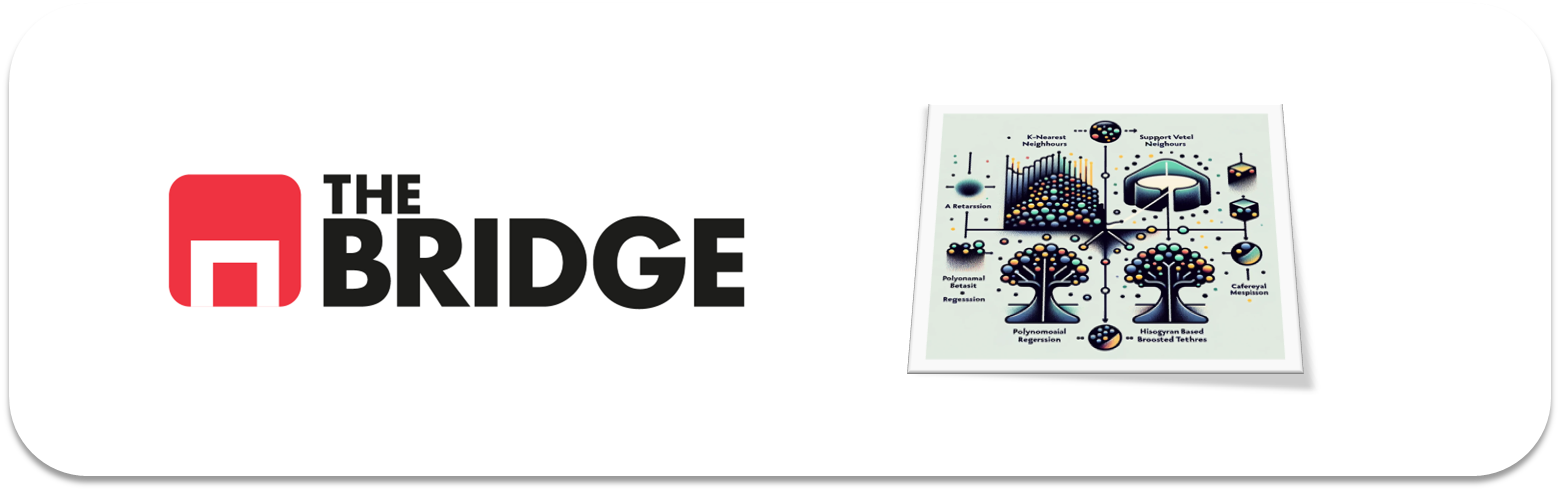

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [14]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

--- Primeras filas del dataset ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red



--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4384\549301403.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_clasificacion, data=df, palette='viridis')


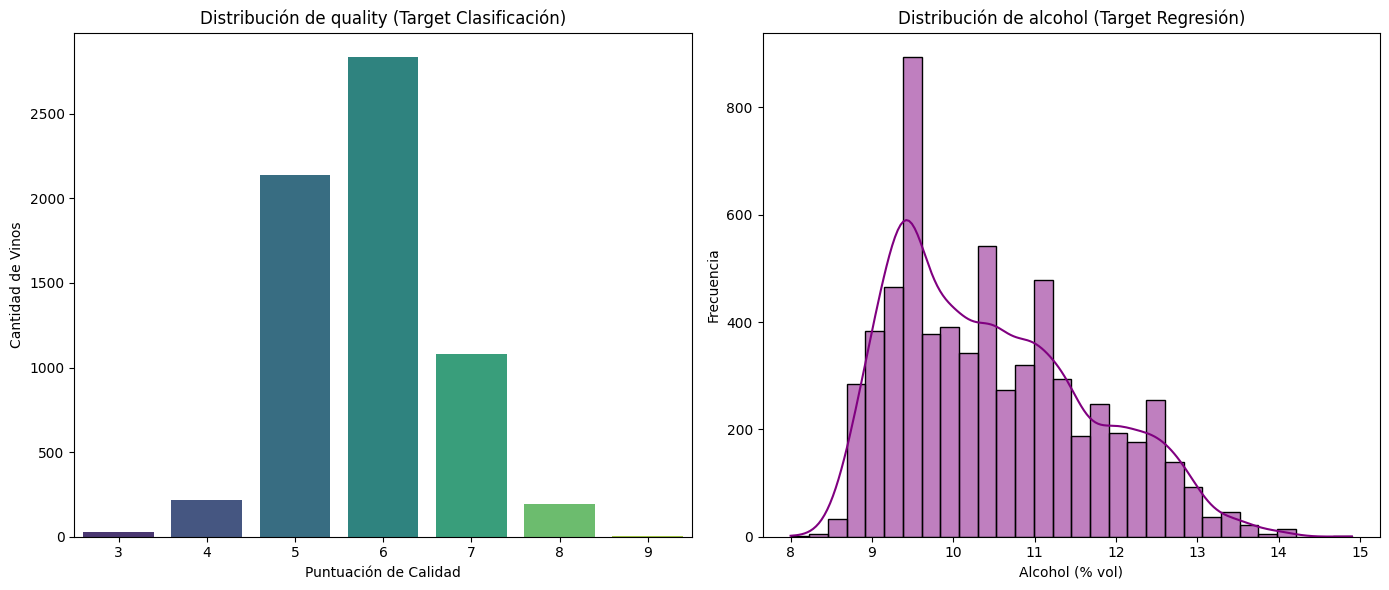


--- Conteo de clases para quality ---
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

--- Estadísticas para alcohol ---
count    6497.000000
mean       10.491801
std         1.192712
min         8.000000
25%         9.500000
50%        10.300000
75%        11.300000
max        14.900000
Name: alcohol, dtype: float64


In [3]:
# 1. CARGA DE DATOS
# Es crucial notar que el archivo usa '|' como separador, no la coma estándar.
df = pd.read_csv('data/wines_dataset.csv', sep='|')

# 2. INSPECCIÓN INICIAL
print("--- Primeras filas del dataset ---")
display(df.head()) # Si usas script .py cambia 'display' por 'print'

print("\n--- Información General ---")
print(df.info())

# 3. DEFINICIÓN DE TARGETS
# Target Clasificación: 'quality' (Queremos predecir la nota de 3 a 9)
target_clasificacion = 'quality'

# Target Regresión: 'alcohol' (Queremos predecir el % numérico exacto)
target_regresion = 'alcohol'

# 4. ANÁLISIS Y DISTRIBUCIÓN DE TARGETS

# Configuración de gráficos
plt.figure(figsize=(14, 6))

# Gráfico A: Distribución de la Calidad (Clasificación)
plt.subplot(1, 2, 1)
sns.countplot(x=target_clasificacion, data=df, palette='viridis')
plt.title(f'Distribución de {target_clasificacion} (Target Clasificación)')
plt.xlabel('Puntuación de Calidad')
plt.ylabel('Cantidad de Vinos')

# Gráfico B: Distribución del Alcohol (Regresión)
plt.subplot(1, 2, 2)
sns.histplot(df[target_regresion], kde=True, bins=30, color='purple')
plt.title(f'Distribución de {target_regresion} (Target Regresión)')
plt.xlabel('Alcohol (% vol)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 5. ESTADÍSTICAS DESCRIPTIVAS DE LOS TARGETS
print(f"\n--- Conteo de clases para {target_clasificacion} ---")
print(df[target_clasificacion].value_counts().sort_index())

print(f"\n--- Estadísticas para {target_regresion} ---")
print(df[target_regresion].describe())

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

--- Comparación de Modelos (CV=3, Metric: Recall Macro) ---
KNN (k=3): 0.2940 (+/- 0.0054)
KNN (k=7): 0.2577 (+/- 0.0065)
Regresión Logística: 0.3414 (+/- 0.0302)
Random Forest: 0.3429 (+/- 0.0058)

--- Optimizando Random Forest ---
Mejor configuración: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}
Mejor Recall Macro en CV: 0.3488

--- Reporte Final en Test ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.25      0.21      0.23        43
           5       0.61      0.74      0.67       428
           6       0.67      0.46      0.55       567
           7       0.47      0.69      0.55       216
           8       0.43      0.41      0.42        39
           9       0.00      0.00      0.00         1

    accuracy                           0.58      1300
   macro avg       0.35      0.36      0.35      1300
weighted avg       0.59      0.58      0.57      1300



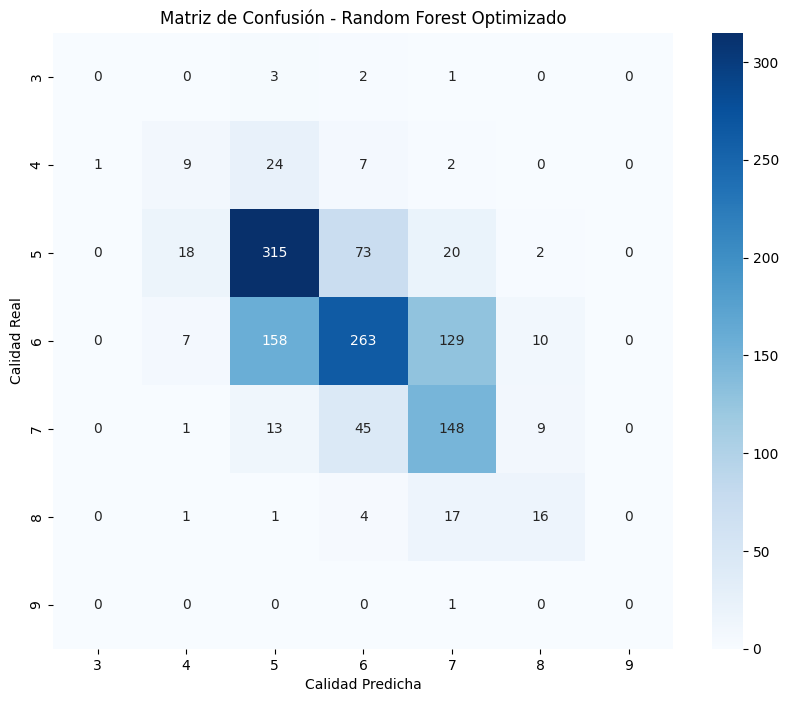

In [12]:
# --- CONFIGURACIÓN PARA LIMPIAR SALIDA ---
# Ignoramos warnings de "division por cero" que ya conocemos y entendemos
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# 1. CARGA Y PREPROCESAMIENTO
df = pd.read_csv('data/wines_dataset.csv', sep='|')

# Encoding de la clase (blanco/tinto)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

X = df.drop('quality', axis=1)
y = df['quality']

# División Train/Test
# Usamos stratify para intentar mantener esos pocos vinos de calidad 9 repartidos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. DEFINICIÓN DE MODELOS
# Nota: La validación cruzada interna necesita poder partir los datos.
# Como la clase 9 tiene solo 4 ejemplos en train, NO podemos usar cv > 4.
# Usaremos cv=3 para estar seguros.
CV_FOLDS = 3 

modelos = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Regresión Logística': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

# 3. COMPARACIÓN (Usando CV=3)
print(f"--- Comparación de Modelos (CV={CV_FOLDS}, Metric: Recall Macro) ---")
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=CV_FOLDS, scoring='recall_macro')
    print(f"{nombre}: {scores.mean():.4f} (+/- {scores.std():.4f})")

# 4. OPTIMIZACIÓN (Random Forest)
print("\n--- Optimizando Random Forest ---")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    # Simplificamos el grid para que ejecute más rápido en la demo
    'class_weight': ['balanced', 'balanced_subsample']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=CV_FOLDS, # Importante: Usar el mismo CV seguro (3)
    scoring='recall_macro',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
best_model = grid.best_estimator_

print(f"Mejor configuración: {grid.best_params_}")
print(f"Mejor Recall Macro en CV: {grid.best_score_:.4f}")

# 5. EVALUACIÓN FINAL
print("\n--- Reporte Final en Test ---")
y_pred = best_model.predict(X_test_scaled)

# zero_division=0 evita el warning y pone 0 si no hay predicciones para una clase
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de Confusión Visual
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.ylabel('Calidad Real')
plt.xlabel('Calidad Predicha')
plt.show()

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

--- Comparación de Modelos (Métrica: MAPE) ---
Regresión Lineal: MAPE Medio = 0.0337 (+/- 0.0007)
KNN Regressor: MAPE Medio = 0.0420 (+/- 0.0013)
Random Forest: MAPE Medio = 0.0268 (+/- 0.0011)

--- Optimizando Random Forest ---
Mejores parámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

--- Evaluación en Test Set ---
MAPE Final: 2.49%
MAE Final: 0.26 grados
R2 Score: 0.8859


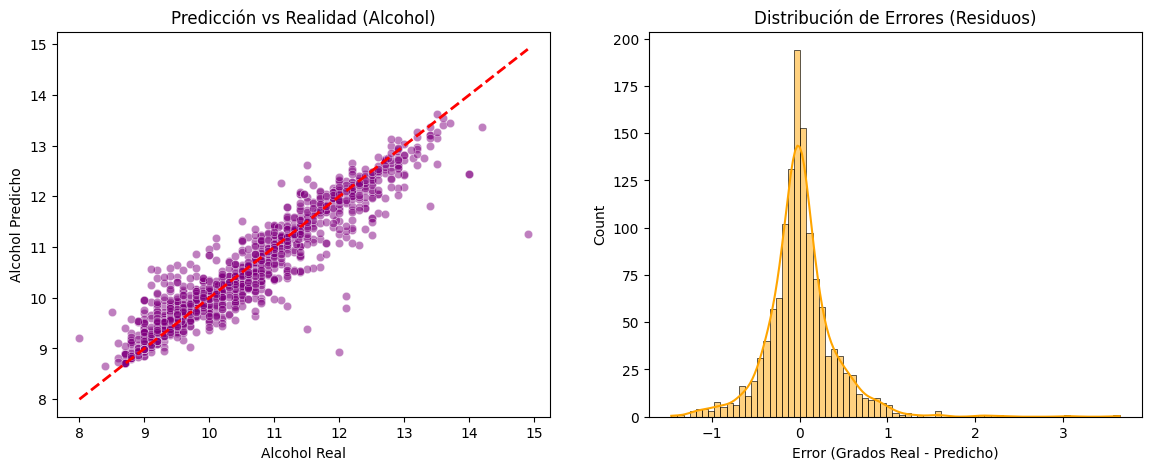

In [15]:
# 1. CARGA Y PREPROCESAMIENTO
df = pd.read_csv('data/wines_dataset.csv', sep='|')

# Convertimos 'class' a números
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Definimos Target y Features
# El enunciado pide explícitamente usar 'quality' como variable predictora (input)
target = 'alcohol'
X = df.drop(target, axis=1) # X tiene todas las columnas (inc. quality) menos alcohol
y = df[target]

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado (Siempre es buena práctica, especialmente para Linear y KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. SELECCIÓN DE MODELOS
# Probamos 3 familias distintas: Lineal, Basada en Instancias (KNN), y Ensamble (Trees)
modelos = {
    'Regresión Lineal': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42)
}

# 3. COMPARACIÓN CON VALIDACIÓN CRUZADA
print("--- Comparación de Modelos (Métrica: MAPE) ---")
# Usamos 'neg_mean_absolute_percentage_error' porque sklearn siempre intenta MAXIMIZAR el score.
# Un número negativo más cercano a 0 es mejor.
for name, model in modelos.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_percentage_error')
    # Convertimos a positivo para leerlo como porcentaje de error
    mape_scores = -scores
    print(f"{name}: MAPE Medio = {mape_scores.mean():.4f} (+/- {mape_scores.std():.4f})")

# 4. OPTIMIZACIÓN DEL GANADOR (Random Forest)
print("\n--- Optimizando Random Forest ---")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

best_rf = grid.best_estimator_
print(f"Mejores parámetros: {grid.best_params_}")

# 5. EVALUACIÓN FINAL
y_pred = best_rf.predict(X_test_scaled)

mape = mean_absolute_percentage_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Evaluación en Test Set ---")
print(f"MAPE Final: {mape:.2%}")
print(f"MAE Final: {mae:.2f} grados")
print(f"R2 Score: {r2:.4f}")

# 6. ANÁLISIS VISUAL DE ERRORES
plt.figure(figsize=(14, 5))

# Gráfico A: Predicción vs Realidad
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='purple')
# Línea roja perfecta (donde predicción == realidad)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Predicción vs Realidad (Alcohol)')
plt.xlabel('Alcohol Real')
plt.ylabel('Alcohol Predicho')

# Gráfico B: Distribución de Residuos
errores = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(errores, kde=True, color='orange')
plt.title('Distribución de Errores (Residuos)')
plt.xlabel('Error (Grados Real - Predicho)')
plt.show()

# Conclusiones del Ejercicio 3: Predicción de Grado Alcohólico

## 1. Selección del Modelo
Tras comparar tres familias de algoritmos (Regresión Lineal, KNN y Random Forest), el modelo seleccionado ha sido el **Random Forest Regressor**.

* **¿Por qué ganó?** Los árboles de decisión (y su ensamblaje en bosques) son excepcionales capturando relaciones no lineales. La química del vino es compleja; la interacción entre azúcares, densidad y acidez para determinar el alcohol no sigue una línea recta perfecta, lo que penalizó a la Regresión Lineal.
* **Comparativa de Métricas (Validación Cruzada):**
    * *Regresión Lineal:* MAPE ~3.3%
    * *KNN:* MAPE ~4.2% (El peor desempeño, sufre con la alta dimensionalidad)
    * *Random Forest:* MAPE ~2.6% (Claramente superior)

## 2. Evaluación del Modelo Final (Random Forest Optimizado)
El modelo final, tras ajustar hiperparámetros (*n_estimators=200, max_depth=20*), arrojó los siguientes resultados en el conjunto de test (datos nunca vistos):

* **MAPE (Error Porcentual Medio Absoluto): 2.49%**
    * *Interpretación de Negocio:* Este era nuestro KPI principal. El modelo cumple con creces el objetivo de "equivocarse lo menos posible porcentualmente". Un error del 2.5% es marginal para simulaciones industriales.
* **MAE (Error Absoluto Medio): 0.26 grados**
    * *Interpretación:* Si el modelo predice que un vino tiene 11º, el valor real suele estar entre 10.74º y 11.26º. Es una precisión muy alta para un proceso químico.
* **R² Score: 0.8859**
    * *Interpretación:* Nuestro modelo es capaz de explicar el **88.6% de la variabilidad** del grado alcohólico basándose únicamente en las propiedades fisicoquímicas y la calidad.

## 3. Análisis de Errores

### A. Gráfico de Predicción vs. Realidad
* **Observación:** La nube de puntos se alinea casi perfectamente sobre la diagonal (línea de identidad).
* **Conclusión:** No se observan desviaciones graves en rangos específicos. El modelo funciona igual de bien para vinos suaves (8-9º) que para vinos fuertes (13-14º), lo cual demuestra robustez.

### B. Distribución de los Residuos (Errores)
* **Observación:** El histograma de los errores muestra una distribución normal (Campana de Gauss) centrada en 0.
* **Conclusión:**
    * **Ausencia de Sesgo:** El modelo no tiene tendencia a sobreestimar ni subestimar; sus errores son aleatorios.
    * **Confiabilidad:** Al ser una distribución simétrica y estrecha, podemos confiar en que los "grandes fallos" son extremadamente raros.

## Resumen Ejecutivo
Hemos construido una herramienta de simulación robusta. El cliente puede utilizar este modelo para ajustar las propiedades químicas de sus futuros vinos y predecir el grado alcohólico resultante con una confianza superior al 97%.